# Feature engineering - feature analysis  | Sebislaw

## Libraries

In [1]:
from os.path  import join
import random
import itertools
import math

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
from pandas.plotting import parallel_coordinates
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

from sklearn.linear_model import LinearRegression, LassoCV, LogisticRegression, LogisticRegressionCV
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score, StratifiedKFold, RandomizedSearchCV
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import brier_score_loss
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif
import xgboost as xgb
from xgboost import XGBClassifier
import optuna
# from tabpfn import TabPFNClassifier

import warnings
warnings.filterwarnings('ignore')

C:\Users\Sebastian\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## Data

In [2]:
data_path = '..\\..\\..\\data'
pd.set_option('display.max_columns', None)

elo = pd.read_csv(join(data_path, 'elo.csv'))
elo['CoachELO'] = elo['CoachELO'].fillna(elo['CoachELO'].mean())
elo = elo.drop(['CoachName'], axis=1)

# The Basics ------------------------------------------------------------------------
# Men
MTeams = pd.read_csv(join(data_path, 'MTeams.csv'))
MSeasons = pd.read_csv(join(data_path, 'MSeasons.csv'))
MNCAATourneySeeds = pd.read_csv(join(data_path, 'MNCAATourneySeeds.csv'))
MRegularSeasonCompactResults = pd.read_csv(join(data_path, 'MRegularSeasonCompactResults.csv'))
MNCAATourneyCompactResults = pd.read_csv(join(data_path, 'MNCAATourneyCompactResults.csv'))
# Women
WTeams = pd.read_csv(join(data_path, 'WTeams.csv'))
WSeasons = pd.read_csv(join(data_path, 'WSeasons.csv'))
WNCAATourneySeeds = pd.read_csv(join(data_path, 'WNCAATourneySeeds.csv'))
WRegularSeasonCompactResults = pd.read_csv(join(data_path, 'WRegularSeasonCompactResults.csv'))
WNCAATourneyCompactResults = pd.read_csv(join(data_path, 'WNCAATourneyCompactResults.csv'))
# Other
SampleSubmissionStage1 = pd.read_csv(join(data_path, 'SampleSubmissionStage1.csv'))
SampleSubmissionStage2 = pd.read_csv(join(data_path, 'SampleSubmissionStage2.csv'))
SeedBenchmarkStage1 = pd.read_csv(join(data_path, 'SeedBenchmarkStage1.csv'))

# Team Box Scores ------------------------------------------------------------------------
# Men
MRegularSeasonDetailedResults = pd.read_csv(join(data_path, 'MRegularSeasonDetailedResults.csv'))
MNCAATourneyDetailedResults = pd.read_csv(join(data_path, 'MNCAATourneyDetailedResults.csv'))
# Women
WRegularSeasonDetailedResults = pd.read_csv(join(data_path, 'WRegularSeasonDetailedResults.csv'))
WNCAATourneyDetailedResults = pd.read_csv(join(data_path, 'WNCAATourneyDetailedResults.csv'))

# Geography ------------------------------------------------------------------------
# All
Cities = pd.read_csv(join(data_path, 'Cities.csv'))
Conferences = pd.read_csv(join(data_path, 'Conferences.csv'))
# Men
MGameCities = pd.read_csv(join(data_path, 'MGameCities.csv'))
# Women
WGameCities = pd.read_csv(join(data_path, 'WGameCities.csv'))

# Public Rankings ------------------------------------------------------------------------
# Men
MMasseyOrdinals = pd.read_csv(join(data_path, 'MMasseyOrdinals.csv')) # men only

# Supplements ------------------------------------------------------------------------
# Men
MTeamCoaches = pd.read_csv(join(data_path, 'MTeamCoaches.csv')) # men only
MTeamConferences = pd.read_csv(join(data_path, 'MTeamConferences.csv'))
MConferenceTourneyGames = pd.read_csv(join(data_path, 'MConferenceTourneyGames.csv'))
MSecondaryTourneyTeams = pd.read_csv(join(data_path, 'MSecondaryTourneyTeams.csv'))
MSecondaryTourneyCompactResults = pd.read_csv(join(data_path, 'MSecondaryTourneyCompactResults.csv'))
MTeamSpellings = pd.read_csv(join(data_path, "MTeamSpellings.csv"), encoding='cp1252')
MNCAATourneySlots = pd.read_csv(join(data_path, 'MNCAATourneySlots.csv'))
MNCAATourneySeedRoundSlots = pd.read_csv(join(data_path, 'MNCAATourneySeedRoundSlots.csv')) # men only
# Women
WTeamConferences = pd.read_csv(join(data_path, 'WTeamConferences.csv'))
WConferenceTourneyGames = pd.read_csv(join(data_path, 'WConferenceTourneyGames.csv'))
WSecondaryTourneyTeams = pd.read_csv(join(data_path, 'WSecondaryTourneyTeams.csv'))
WSecondaryTourneyCompactResults = pd.read_csv(join(data_path, 'WSecondaryTourneyCompactResults.csv'))
WTeamSpellings = pd.read_csv(join(data_path, 'WTeamSpellings.csv'), encoding='cp1252')
WNCAATourneySlots = pd.read_csv(join(data_path, 'WNCAATourneySlots.csv'))

## Data preparation pipeline

In [3]:
def prepare_data(df):
        
    """
    This function duplicates and flips a game record.
    Now two records with the same data are present, 
    but viewed from perspectives of two different teams.
    """
    
    df = df[[
         'Season', 'DayNum', 'NumOT',
         'WTeamID',  'WScore', 'WLoc',
         'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF',
         'LTeamID', 'LScore',
         'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF'
    ]]
    dfswap = df[[
         'Season', 'DayNum', 'NumOT',
         'LTeamID', 'LScore', 'WLoc',
         'LFGM', 'LFGA', 'LFGM3', 'LFGA3', 'LFTM', 'LFTA', 'LOR', 'LDR', 'LAst', 'LTO', 'LStl', 'LBlk', 'LPF',
         'WTeamID',  'WScore',
         'WFGM', 'WFGA', 'WFGM3', 'WFGA3', 'WFTM', 'WFTA', 'WOR', 'WDR', 'WAst', 'WTO', 'WStl', 'WBlk', 'WPF',
    ]].copy()
    
    dfswap.loc[df['WLoc'] == 'H', 'WLoc'] = 'A'
    dfswap.loc[df['WLoc'] == 'A', 'WLoc'] = 'H'
        
    df = df.rename(columns={'WLoc': 'location'})
    dfswap = dfswap.rename(columns={'WLoc': 'location'})
        
    df.columns = [x.replace('W','T1_').replace('L','T2_') for x in list(df.columns)]
    dfswap.columns = [x.replace('L','T1_').replace('W','T2_') for x in list(dfswap.columns)]
    
    output = pd.concat([df, dfswap]).reset_index(drop=True)
    output.loc[output.location=='N','location'] = '0'
    output.loc[output.location=='H','location'] = '1'
    output.loc[output.location=='A','location'] = '-1'
    output.location = output.location.astype(int)
        
    output['PointDiff'] = output['T1_Score'] - output['T2_Score']
    
    return output

def get_data(regular_results, tourney_results, seeds, prepared=False, location_multiplier=[1, 1], win_ratio_days_back=14):

    """
    This function uses the prepare_data function in order to create
    a data frame with season statistics for each team.
    These statistics are added to records with games played in
    tournament to make data 'x' used in model to predict the game 
    result 'y'. The output is a data frame that contains data 'x'
    and also label 'y' can be easily calculated based on score difference in matches.
    """

    if prepared:
        regular_data = regular_results.copy()
        tourney_data = tourney_results.copy()
    else:
        # make data frames with extra rows to represent the perspective of losing team
        regular_data = prepare_data(regular_results)
        tourney_data = prepare_data(tourney_results)

    # ----------------------------------- Add reward/penalty for playing in home or away
    if location_multiplier[0] == 1 and location_multiplier[1] == 1:
        # data frame with mean game statistics for a given team in a given season
        season_statistics  = regular_data.groupby(["Season", 'T1_TeamID'])[
            [
                'T1_Score', 'T1_FGM','T1_FGA','T1_FGM3','T1_FGA3','T1_FTM','T1_FTA',
                'T1_OR','T1_DR','T1_Ast','T1_TO','T1_Stl','T1_Blk','T1_PF',
                'T2_Score', 'T2_FGM','T2_FGA','T2_FGM3','T2_FGA3','T2_FTM','T2_FTA',
                'T2_OR','T2_DR','T2_Ast','T2_TO','T2_Stl','T2_Blk','T2_PF',
                'PointDiff'
            ]
        ].agg('mean').reset_index()
    else:
        # Define which columns to adjust (you can add or remove columns as needed)
        T1_cols = ['T1_Score','T1_FGM','T1_FGA','T1_FGM3','T1_FGA3','T1_FTM','T1_FTA','T1_OR','T1_DR','T1_Ast','T1_TO','T1_Stl','T1_Blk','T1_PF']
        T2_cols = ['T2_Score','T2_FGM','T2_FGA','T2_FGM3','T2_FGA3','T2_FTM','T2_FTA','T2_OR','T2_DR','T2_Ast','T2_TO','T2_Stl','T2_Blk','T2_PF']
    
        # Convert the relevant columns to float before applying the adjustment function.
        cols_to_float = T1_cols + T2_cols
        regular_data[cols_to_float] = regular_data[cols_to_float].astype(float)
        
        def adjust_stats(row):
            # Determine multipliers based on location
            if row['location'] == 1:
                factor_T1 = location_multiplier[0]  # penalize Team1 stats (home)
                factor_T2 = location_multiplier[1]  # boost Team2 stats
            elif row['location'] == -1:
                factor_T1 = location_multiplier[1]  # boost Team1 stats (away)
                factor_T2 = location_multiplier[0]  # penalize Team2 stats
            else:
                factor_T1 = 1.0
                factor_T2 = 1.0
        
            # Adjust Team1 stats
            for col in T1_cols:
                if col in row and pd.notnull(row[col]):
                    row[col] = row[col] * factor_T1
        
            # Adjust Team2 stats
            for col in T2_cols:
                if col in row and pd.notnull(row[col]):
                    row[col] = row[col] * factor_T2
        
            # Recalculate derived statistics (if needed)
            if 'T1_Score' in row and 'T2_Score' in row:
                row['PointDiff'] = row['T1_Score'] - row['T2_Score']
            return row
        
        # Apply the adjustment function row-wise.
        regular_data_adjusted = regular_data.apply(adjust_stats, axis=1)
        
        # Now group by Season and T1_TeamID to compute season averages for the adjusted statistics.
        stats_columns = T1_cols[1:] + T2_cols[1:] + ['PointDiff']  # Exclude T1_TeamID from stats if present.
        season_statistics = regular_data_adjusted.groupby(["Season", 'T1_TeamID'])[stats_columns].agg('mean').reset_index()
    # -----------------------------------
    
    # mean statistics for team and team's opponent's
    season_statistics_T1 = season_statistics.copy()
    season_statistics_T2 = season_statistics.copy()
    
    season_statistics_T1.columns = ["T1_" + x.replace("T1_","").replace("T2_","opponent_") for x in list(season_statistics_T1.columns)]
    season_statistics_T2.columns = ["T2_" + x.replace("T1_","").replace("T2_","opponent_") for x in list(season_statistics_T2.columns)]
    season_statistics_T1.columns.values[0] = "Season"
    season_statistics_T2.columns.values[0] = "Season"
    season_statistics_T1 = season_statistics_T1.rename(columns={'T1_Score': 'T1_Score_mean'})
    season_statistics_T2 = season_statistics_T2.rename(columns={'T2_Score': 'T2_Score_mean'})
    
    # data frame containing game's result
    tourney_data = tourney_data[['Season', 'DayNum', 'T1_TeamID', 'T1_Score', 'T2_TeamID' ,'T2_Score', 'location']]
    tourney_data = pd.merge(tourney_data, season_statistics_T1, on = ['Season', 'T1_TeamID'], how = 'left')
    tourney_data = pd.merge(tourney_data, season_statistics_T2, on = ['Season', 'T2_TeamID'], how = 'left')

    calculate_win_ratio_days_back = 132 - win_ratio_days_back
    
    # data frame with win fraction from last x days for a given team in a given season
    last14days_stats_T1 = regular_data.loc[regular_data.DayNum>calculate_win_ratio_days_back].reset_index(drop=True)
    last14days_stats_T1['win'] = np.where(last14days_stats_T1['PointDiff']>0,1,0)
    last14days_stats_T1 = last14days_stats_T1.groupby(['Season','T1_TeamID'])['win'].mean().reset_index(name='T1_win_ratio_14d')
    
    last14days_stats_T2 = regular_data.loc[regular_data.DayNum>calculate_win_ratio_days_back].reset_index(drop=True)
    last14days_stats_T2['win'] = np.where(last14days_stats_T2['PointDiff']<0,1,0)
    last14days_stats_T2 = last14days_stats_T2.groupby(['Season','T2_TeamID'])['win'].mean().reset_index(name='T2_win_ratio_14d')
    
    # add to tourney_data column with win fraction for winning and losing team
    tourney_data = pd.merge(tourney_data, last14days_stats_T1, on = ['Season', 'T1_TeamID'], how = 'left')
    tourney_data = pd.merge(tourney_data, last14days_stats_T2, on = ['Season', 'T2_TeamID'], how = 'left')
    
    # get seeds with no regional division
    seeds['seed'] = seeds['Seed'].apply(lambda x: int(x[1:3]))
    
    # give each team a raw seed
    seeds_T1 = seeds[['Season','TeamID','seed']].copy()
    seeds_T2 = seeds[['Season','TeamID','seed']].copy()
    seeds_T1.columns = ['Season','T1_TeamID','T1_seed']
    seeds_T2.columns = ['Season','T2_TeamID','T2_seed']
    
    # add seeds to turney data for team 1 and team 2
    tourney_data = pd.merge(tourney_data, seeds_T1, on = ['Season', 'T1_TeamID'], how = 'left')
    tourney_data = pd.merge(tourney_data, seeds_T2, on = ['Season', 'T2_TeamID'], how = 'left')
    
    # add a seed difference column
    tourney_data["Seed_diff"] = tourney_data["T1_seed"] - tourney_data["T2_seed"]

    return tourney_data

def get_df(seeds,
            season_games, season_range, days_back,
            tourney_games, tourney_range, 
            location_multiplier=[1, 1],
           win_ratio_days_back=14):

    """
    This function uses get_data function to get a data
    frame which is then used to make 'x' and 'y' data
    used in models.
    """
    
    # Get from regular season games from specified season range and days back
    # The results of those games will be used as team statictics (additional team information for tourney games)
    regular_results = season_games[season_games['Season'].isin(season_range)]
    regular_results = regular_results[regular_results['DayNum'] > 134 - days_back]
    
    # Get tourney games from a specified season
    # The results of those games will be used as labels
    tourney_results = tourney_games[tourney_games['Season'].isin(tourney_range)]
    
    # Get final data frame
    df = get_data(regular_results, tourney_results, seeds, location_multiplier=[1, 1], win_ratio_days_back=win_ratio_days_back)
    
    return df

def get_final_df(seeds,
                   season_games, season_range, days_back,
                   tourney_games, tourney_range, 
                   SampleSubmissionStage1,
                  location_multiplier=[1, 1],
                win_ratio_days_back=14):

    """
    This function works the same as function get_x_y,
    but also creates (at the moment it's the same as get_x_y)
    aditional data points mostly with NaN values that matches
    the submission format (parsed team matchups with the sample submission file).
    """

    # Get from regular season games from specified season range and days back
    # The results of those games will be used as team statictics (additional team information for tourney games)
    regular_results = season_games[season_games['Season'].isin(season_range)]
    regular_results = regular_results[regular_results['DayNum'] > 134 - days_back]

    # Get tourney games from a specified season
    # The results of those games will be used as labels
    tourney_results = tourney_games[tourney_games['Season'].isin(tourney_range)]
    
    # Assume sample_submission is a DataFrame with an "ID" column like "2023_1101_1102"
    # and tourney_results is a DataFrame with columns including: Season, WTeamID, LTeamID, DayNum, WScore, LScore, WLoc, etc.
    # Filter rows where the ID starts with the specified season (followed by an underscore)
    final_season = tourney_range[0]
    sample_submission_copy = SampleSubmissionStage1.copy()
    sample_submission = sample_submission_copy[sample_submission_copy['ID'].str.startswith(f"{final_season}_")]
    sample_submission = sample_submission.drop(columns=['Pred'])
    
    sample_submission[['Season', 'Team1', 'Team2']] = sample_submission['ID'].str.split('_', expand=True)
    sample_submission['Season'] = sample_submission['Season'].astype(float)
    sample_submission['Team1'] = sample_submission['Team1'].astype(float)
    sample_submission['Team2'] = sample_submission['Team2'].astype(float)
    
    regular_data_final = prepare_data(regular_results)
    tourney_data_final  = prepare_data(tourney_results)
    
    tourney_data =  get_data(regular_data_final, tourney_data_final,
                             seeds, prepared=True,
                          win_ratio_days_back=win_ratio_days_back)
    tourney_data = pd.merge(
        sample_submission,
        tourney_data,
        left_on=['Season', 'Team1', 'Team2'],
        right_on=['Season', 'T1_TeamID', 'T2_TeamID'],
        how='left'
    )
    tourney_data['T1_TeamID'] = tourney_data['Team1']
    tourney_data['T2_TeamID'] = tourney_data['Team2']
    tourney_data = tourney_data.drop(['ID', 'Team1', 'Team2'], axis=1)
    
    return tourney_data

def correct_predictions_based_on_seed(x, y, maximum_favoured_seed = 4, number_of_added_columns=1):
    """
    Sets the winnning chance to 1 or 0 based on the seed difference.
    """
    for i in range(len(x)):
        if x[i][-1-number_of_added_columns] <= (-16 + maximum_favoured_seed * 2 - 1):
            y[i] = 1
        elif x[i][-1-number_of_added_columns] >= (16 - maximum_favoured_seed * 2 + 1):
            y[i] = 0
    return y

def clear_na_from_x_y(x, y):
    """
    The data frame for final season is in format matching the submission file.
    This function clears NaNs from data.
    """
    # Create masks for training data:
    mask_train = ~np.isnan(x).any(axis=1) & ~np.isnan(y)
    x_clean = x[mask_train]
    y_clean = y[mask_train]
    return x_clean, y_clean

def x_y_from_data_frame(df):
    # Prepare data and labels
    x = df[list(df.columns[7:])].values
    y = np.where(
        df[['T1_Score', 'T2_Score']].isnull().any(axis=1),
        np.nan,
        np.where(df['T1_Score'] - df['T2_Score'] > 0, 1, 0)
    )
    return x, y

def get_all_core_data(
    regular_results, tourney_results, seeds, SampleSubmissionStage1,
    final_season = 2024, # the season we want to predict, so for out submission it will be 2025
    start_season = 2005, # from which ponit should we begin creating data
    season_years_list  = [[i-1, i] for i in range(2005, 2024+1)], # at which seasons to look at when calculating team's stats
    days_back = 15, # how many days back from the start of tourney to calculate team's stats per season
    maximum_favoured_seed = 4, # Set the predicted probability of winning to 1 for seeds <= maximum_favoured_seed and to 0 for >= 16-maximum_favoured_seed
    location_multiplier=[0.95, 1.05], # home penalty, away bonus 
    include_men = True, # include M... data sets when preparing x and y
    include_women = True, # include W... data sets when preparing x and y
    win_ratio_days_back = 14):

    """
    The idea of this function is to easily get data needed to train and test the model later on, with minimal code
    to not clutter the netebook.
    
    This function outputs df, x, y, df_final, x_final_season, y_final_season.
    
    df is a data frame with first 6 columns from tourney games and other calculated from other data frames.
    
    Adding a column to df and executing x_y_from_data_frame(df) function will yield x with added data.
    
    Note that df_final has the same structure as df, but also with rows with NaNs. The rows with missing information are there
    to match the sumbission file format. The separation of those data frames is to ensure that information from last season doesn't
    leak into training data due to poorly written code.
    
    x has df columns from location onwardsthe columns before that are from tourney games and are used to calculate y (based on points).
    
    y has label 0 or 1 (lose or win) and nan if the correspoinding data in x was nan.
    
    There is also x_final_season and y_final_season aquired from df_final, which are the same as x and y, but like df_final, they have NaNs. 
    """

    # This ensures that we simulate the scenario in competition
    tourney_results_final = tourney_results[tourney_results['Season'] == final_season]
    tourney_results = tourney_results[tourney_results['Season'] < final_season]
    regular_results = regular_results[regular_results['Season'] != 2020] # This year had no tournament data
    tourney_years_list = [[i] for i in range(start_season, final_season+1)]
    
    # Arrays to store data
    data = []
    x = []
    y = []
    data_final = []
    x_final_season = []
    y_final_season = []
    for season_years, tourney_years in zip(season_years_list, tourney_years_list):
        if tourney_years[0] != 2020: # This year had no tournament data
            
            # Create data separately for the final tournament
            if tourney_years[0] == final_season:
                data_tmp_final = get_final_df(
                    seeds,
                    regular_results, season_years, days_back,
                    tourney_results_final, tourney_years, 
                    SampleSubmissionStage1,
                    location_multiplier=location_multiplier,
                    win_ratio_days_back=win_ratio_days_back
                )
                # Array to store data
                data_final.append(data_tmp_final)
                
            else:
                # Create data separately for the rest of games besides for the final tournament
                data_tmp = get_df(
                    seeds,
                    regular_results, season_years, days_back,
                    tourney_results, tourney_years,
                    location_multiplier=location_multiplier,
                    win_ratio_days_back=win_ratio_days_back
                )
                # Array to store data
                data.append(data_tmp)
    
    
    
    # complete data from which x and y can be calculated + more for all tournament games besides for the final tournament
    df = pd.concat(data, ignore_index=True)
    
    # the same as df, but only for the final tournament
    df_final = pd.concat(data_final, ignore_index=True)
    
    return df, df_final

## Which features are important for men?

In [78]:
# PARAMETERS TO CHANGE
final_season = 2024 # the season we want to predict, so for out submission it will be 2025
start_season = 2003 # from which ponit should we begin creating data
season_years_list  = [[i] for i in range(start_season, final_season+1)] # at which seasons to look at when calculating team's stats
days_back = 14 # how many days back from the start of tourney to calculate team's stats per season
maximum_favoured_seed = 1 # Set the predicted probability of winning to 1 for seeds <= maximum_favoured_seed and to 0 for >= 16-maximum_favoured_seed
location_multiplier = [0.95, 1.05] # home penalty, away bonus ex.
win_ratio_days_back = 14

In [127]:
# ----------------------------------------------------------

include_men = True # include M... data sets when preparing x and y
include_women = False # include W... data sets when preparing x and y

# ----------------------------------------------------------

# READ DATA
regular_results = pd.concat([
    MRegularSeasonDetailedResults.copy() if include_men else None,
    WRegularSeasonDetailedResults.copy() if include_women else None
], ignore_index=True)
tourney_results = pd.concat([
    MNCAATourneyDetailedResults.copy() if include_men else None,
    WNCAATourneyDetailedResults.copy() if include_women else None
], ignore_index=True)
seeds = pd.concat([
    MNCAATourneySeeds.copy() if include_men else None,
    WNCAATourneySeeds.copy() if include_women else None
], ignore_index=True)
number_of_added_columns = 0 # If you add any columns AFTER obtaining data from get_all_core_data change this counter

# ----------------------------------------------------------

# GET ALL DATA NEEDED TO USE THE MODELS
df_train, df_test = get_all_core_data(
    regular_results, tourney_results, seeds, SampleSubmissionStage1, final_season = final_season,
    start_season = start_season, season_years_list  = season_years_list, days_back = days_back,
    maximum_favoured_seed = maximum_favoured_seed, location_multiplier=location_multiplier,
    include_men = include_men, include_women = include_women, win_ratio_days_back = win_ratio_days_back)
#     data_to_include = data_to_include)

# ----------------------------------------------------------

# ADD TEAM AND COACH ELO AND REPLACE NAN WITH MEAN

if include_men:
    elo = pd.read_csv(join(data_path, 'elo.csv'))
    elo['CoachELO'] = elo['CoachELO'].fillna(elo['CoachELO'].mean())

    def add_elo_column(df):
        df = df.copy()
        df = pd.merge(
                df,
                elo[['Season', 'DayNum', 'TeamID', 'TeamELO', 'CoachELO']],
                left_on=['Season', 'DayNum', 'T1_TeamID'],
                right_on=['Season', 'DayNum', 'TeamID'],
                how='left'
            )
        df = df.drop(['TeamID'], axis=1)
    #     x, y = x_y_from_data_frame(df)
        return df

    df_train = add_elo_column(df_train)
    df_test = add_elo_column(df_test)

    number_of_added_columns = 2
    
# ----------------------------------------------------------
    
x_train, y_train = x_y_from_data_frame(df_train)
x_test, y_test = x_y_from_data_frame(df_test)
df_train_x = df_train.iloc[:, 7:]

x_train, y_train = clear_na_from_x_y(x_train.copy(), y_train.copy())
x_test, y_test = clear_na_from_x_y(x_test.copy(), y_test.copy())
df_test_x = df_test.iloc[:, 7:]

C:\Users\Sebastian\anaconda3\lib\site-packages\pandas\core\reshape\merge.py:1204: RuntimeWarning:

invalid value encountered in cast



In [128]:
def plot_correlation_matrix(df):
    """
    Plots a heatmap of the correlation matrix for all numeric columns in df.
    """
    corr = df.corr()
    # Create a mask to display only the lower triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))
    plt.figure(figsize=(32, 32))
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", square=True)
    plt.title("Correlation Matrix")
    plt.show()
    
# ------------------------------------------

def plot_parallel_coordinates_by_label(df, y):
    """
    Creates a parallel coordinates plot for the DataFrame df, using y (a NumPy array
    with labels 0 or 1) to color the lines.
    
    Parameters:
        df : pandas DataFrame
            DataFrame containing only numeric features.
        y : numpy array
            Array of binary labels (0 or 1) with the same number of rows as df.
    """
    # Create a copy and add the label column
    df_plot = df.copy()
    df_plot['label'] = y.astype(str)  # Convert labels to string for grouping
    
    plt.figure(figsize=(32, 8))
    parallel_coordinates(df_plot, 'label', colormap='coolwarm')
    plt.title("Parallel Coordinates Plot by Label")
    plt.xlabel("Features")
    plt.ylabel("Value")
    plt.legend(title="Label", loc="upper right")
    plt.show()
    
# ------------------------------------------
    
def interactive_parallel_coordinates(df, y, dimensions):
    """
    Plots an interactive parallel coordinates plot using Plotly.
    
    Parameters:
      df: pandas DataFrame with numeric features.
      y: numpy array (or pd.Series) with binary labels (0 or 1).
      dimensions: list of column names (from df) to include in the plot.
    """
    # Create a copy and add the label column as an integer.
    df_plot = df.copy()
    df_plot['label'] = pd.Series(y).astype(int)
    
    # Build the plot using the selected dimensions.
    # We add 'label' as the color column so that lines are colored based on label.
    fig = px.parallel_coordinates(
        df_plot,
        dimensions=dimensions,
        color="label",
        color_continuous_scale=px.colors.diverging.Tealrose,
        color_continuous_midpoint=0.5,
        labels={'label': 'Label'}
    )
    fig.update_layout(title="Parallel Coordinates Plot")
    fig.show()

# ------------------------------------------
        
def select_top_features_by_mutual_info(X, y, top_k=10):
    """
    Select the top_k features from X based on mutual information with y.
    
    Parameters:
        X (pd.DataFrame): Feature DataFrame.
        y (array-like): Target vector (binary labels).
        top_k (int): Number of top features to select.
        
    Returns:
        list: Names of the top_k features.
    """
    # Compute mutual information scores for each feature.
    mi_scores = mutual_info_classif(X, y, random_state=42)
    
    # Get indices of the top_k features (largest MI values)
    top_features_idx = np.argsort(mi_scores)[-top_k:]
    
    # Return the feature names corresponding to these indices
    return X.columns[top_features_idx].tolist()

def plot_mutual_info(X, y):
    # Compute mutual information scores for each feature.
    mi_scores = mutual_info_classif(X, y, random_state=42)
    # Create a Series with feature names as index.
    mi_series = pd.Series(mi_scores, index=X.columns)
    # Sort the scores in descending order.
    mi_series = mi_series.sort_values(ascending=False)
    
    # Plot the scores
    plt.figure(figsize=(12, 6))
    mi_series.plot(kind='bar')
    plt.title("Mutual Information Scores for Features")
    plt.xlabel("Features")
    plt.ylabel("Mutual Information Score")
    plt.tight_layout()
    plt.show()

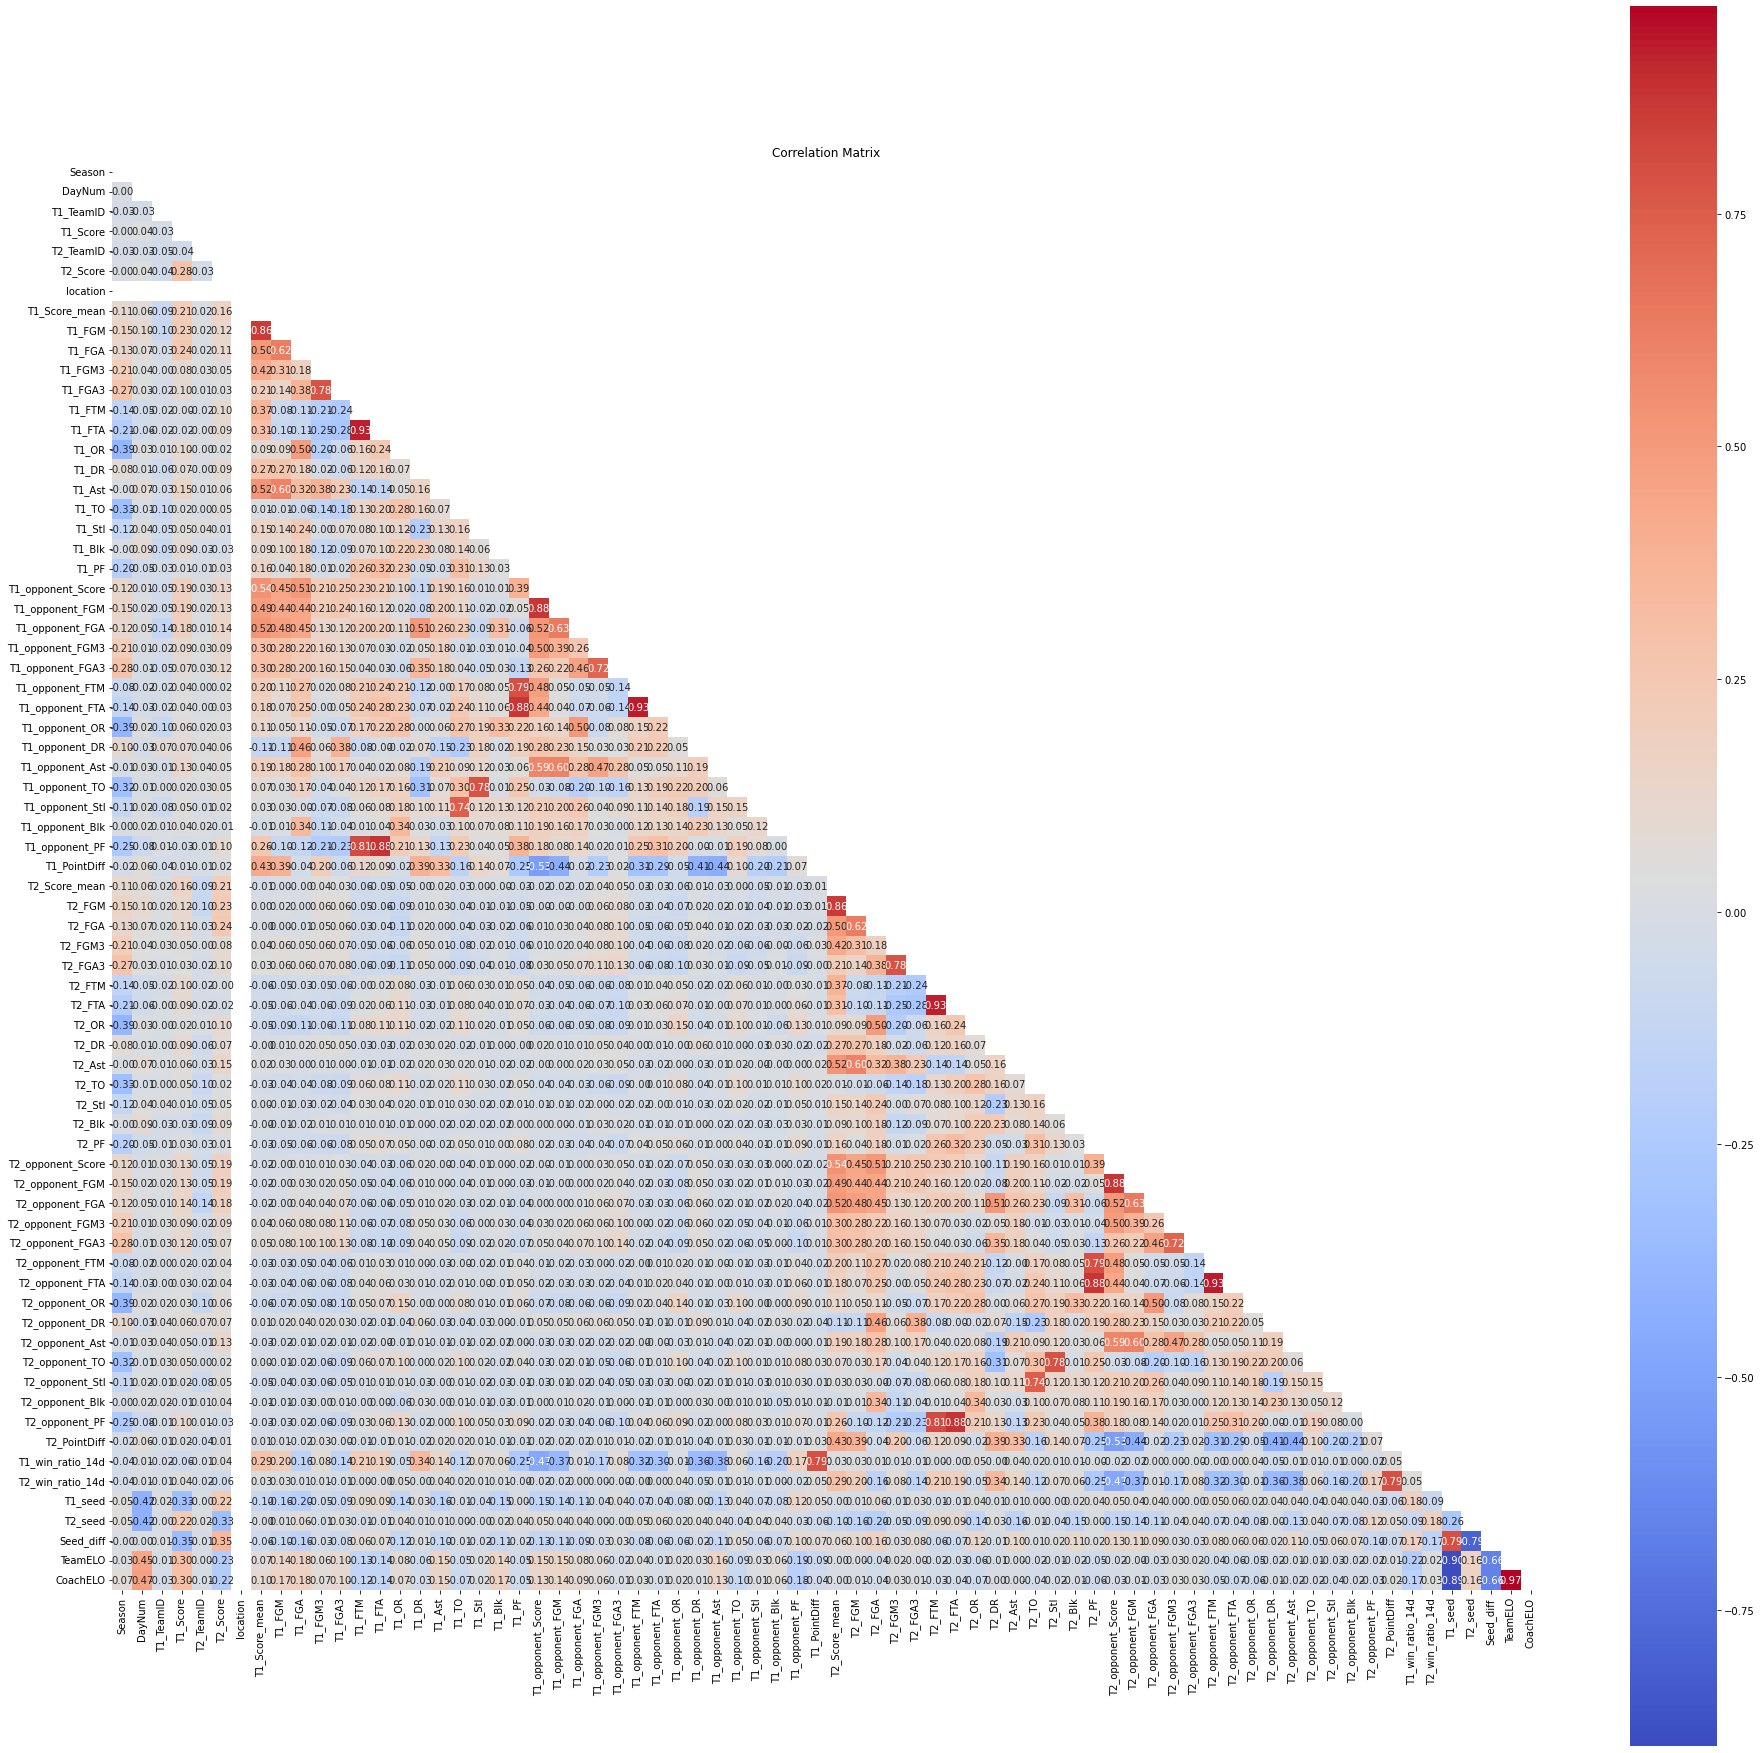

In [129]:
plot_correlation_matrix(df_train)

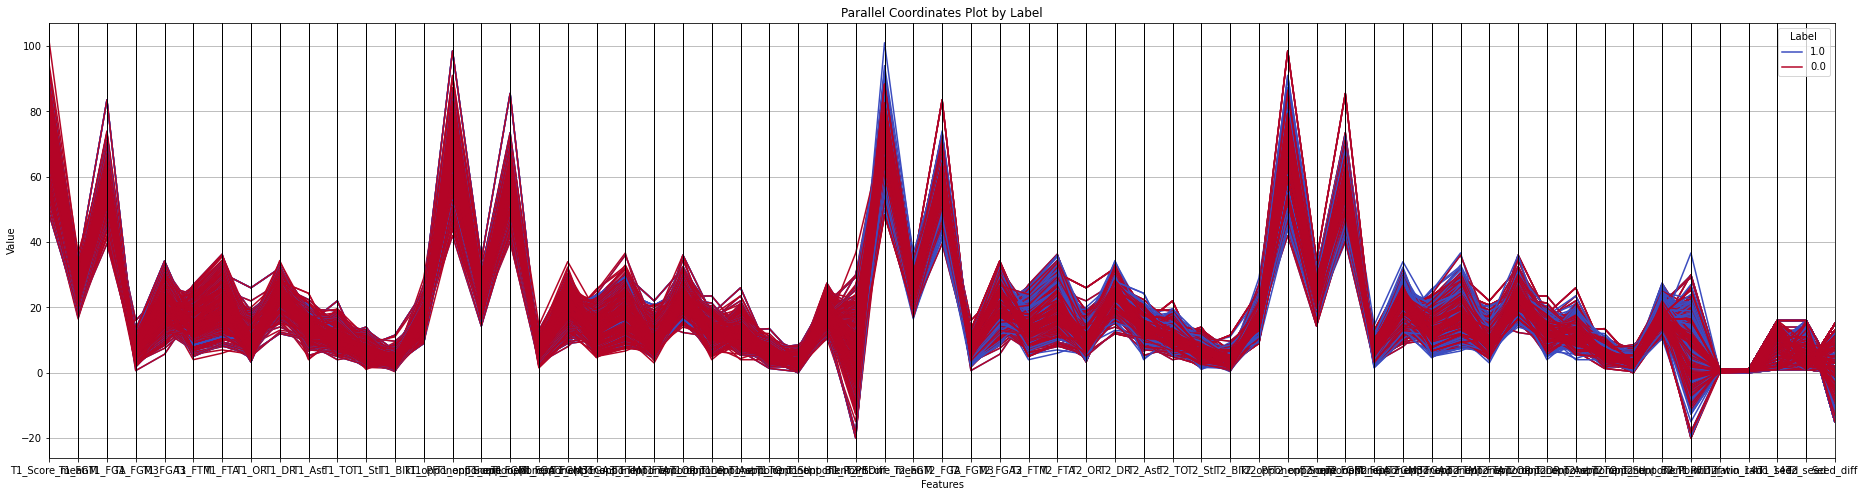

In [130]:
plot_parallel_coordinates_by_label(df_train_x.iloc[:, :-2], y_train)

In [131]:
feature_selector = widgets.SelectMultiple(
    options=list(df_train.columns),
    value=list(df_train.columns)[:5],  # default selection: first 5 features
    description='Features',
    disabled=False,
    layout=widgets.Layout(width='500px', height='300px')
)


def update_plot(selected_features):
    if selected_features:
        interactive_parallel_coordinates(df_train, y_train, list(selected_features))
    else:
        print("Please select at least one feature.")

# Create the interactive widget.
interactive_plot = widgets.interactive(update_plot, selected_features=feature_selector)
display(interactive_plot)

interactive(children=(SelectMultiple(description='Features', index=(0, 1, 2, 3, 4), layout=Layout(height='300p…

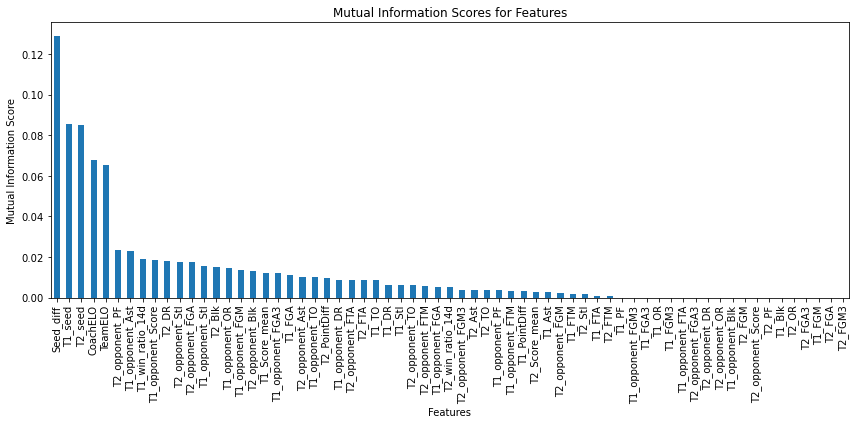

Top features by mutual information: ['T1_FGA', 'T1_opponent_FGA3', 'T1_Score_mean', 'T2_opponent_Blk', 'T1_opponent_FGM', 'T1_opponent_OR', 'T2_Blk', 'T1_opponent_Stl', 'T2_opponent_FGA', 'T2_opponent_Stl', 'T2_DR', 'T1_opponent_Score', 'T1_win_ratio_14d', 'T1_opponent_Ast', 'T2_opponent_PF', 'TeamELO', 'CoachELO', 'T2_seed', 'T1_seed', 'Seed_diff']


In [132]:
# Example usage:
# Assuming df is your DataFrame with numeric features and y is your label array.
plot_mutual_info(df_train_x, y_train)

# Example usage:
selected_features = select_top_features_by_mutual_info(df_train_x, y_train, top_k=20)
print("Top features by mutual information:", selected_features)

In [133]:
columns_to_include = df_train.columns[:6].tolist() + [ 
                      'TeamELO', 'CoachELO', 'Seed_diff',
    'T1_opponent_PF', 
                    
]
x_train, y_train = x_y_from_data_frame(df_train[columns_to_include])
x_test, y_test = x_y_from_data_frame(df_test[columns_to_include])

df_train_x = df_train[columns_to_include].iloc[:, 6:]
df_test_x = df_test[columns_to_include].iloc[:, 6:]

x_train, y_train = clear_na_from_x_y(x_train.copy(), y_train.copy())
x_test, y_test = clear_na_from_x_y(x_test.copy(), y_test.copy())

In [134]:
print('LogisticRegressionCV')

# Create a pipeline with StandardScaler and LogisticRegressionCV
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegressionCV(
        cv=5,                # 5-fold cross-validation
        solver='lbfgs',
        max_iter=2000,       # Increase max_iter if needed
        scoring='neg_log_loss',  # Optimize log-loss for probability calibration
        refit=True
    ))
])

# Train the model using the pipeline
pipeline.fit(x_train, y_train)

y_prob = pipeline.predict_proba(x_test)[:, 1]
score = brier_score_loss(y_test, y_prob)
print("Brier score:", score)

# -----------------------------------------------------------

print('XGBClassifier')

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

# Train the model using the pipeline
pipeline.fit(x_train, y_train)

# Predict probabilities for the positive class
y_prob = pipeline.predict_proba(x_test)[:, 1]

# Calculate the Brier score
score = brier_score_loss(y_test, y_prob)
print("Brier score:", score)

LogisticRegressionCV
Brier score: 0.19336744353120341
XGBClassifier
Brier score: 0.202062496101468


## Which features are important for women?

In [86]:
# ----------------------------------------------------------

# PARAMETERS TO CHANGE
include_men = False
include_women = True

# ----------------------------------------------------------

# READ DATA
regular_results = pd.concat([
    MRegularSeasonDetailedResults.copy() if include_men else None,
    WRegularSeasonDetailedResults.copy() if include_women else None
], ignore_index=True)
tourney_results = pd.concat([
    MNCAATourneyDetailedResults.copy() if include_men else None,
    WNCAATourneyDetailedResults.copy() if include_women else None
], ignore_index=True)
seeds = pd.concat([
    MNCAATourneySeeds.copy() if include_men else None,
    WNCAATourneySeeds.copy() if include_women else None
], ignore_index=True)
number_of_added_columns = 0 # If you add any columns AFTER obtaining data from get_all_core_data change this counter

# ----------------------------------------------------------

# GET ALL DATA NEEDED TO USE THE MODELS
df_train, df_test = get_all_core_data(
    regular_results, tourney_results, seeds, SampleSubmissionStage1, final_season = final_season,
    start_season = start_season, season_years_list  = season_years_list, days_back = days_back,
    maximum_favoured_seed = maximum_favoured_seed, location_multiplier=location_multiplier,
    include_men = include_men, include_women = include_women, win_ratio_days_back = win_ratio_days_back)

# ----------------------------------------------------------

# ADD TEAM AND COACH ELO AND REPLACE NAN WITH MEAN

if include_women:
    elo = pd.read_csv(join(data_path, 'elo.csv'))

    def add_elo_column(df):
        df = df.copy()
        df = pd.merge(
                df,
                elo[['Season', 'DayNum', 'TeamID', 'TeamELO']],
                left_on=['Season', 'DayNum', 'T1_TeamID'],
                right_on=['Season', 'DayNum', 'TeamID'],
                how='left'
            )
        df = df.drop(['TeamID'], axis=1)
        return df

    df_train = add_elo_column(df_train)
    df_test = add_elo_column(df_test)

    number_of_added_columns = 1
    
# ----------------------------------------------------------
    
x_train, y_train = x_y_from_data_frame(df_train)
x_test, y_test = x_y_from_data_frame(df_test)
df_train_x = df_train.iloc[:, 7:]

x_train, y_train = clear_na_from_x_y(x_train.copy(), y_train.copy())
x_test, y_test = clear_na_from_x_y(x_test.copy(), y_test.copy())
df_test_x = df_test.iloc[:, 7:]

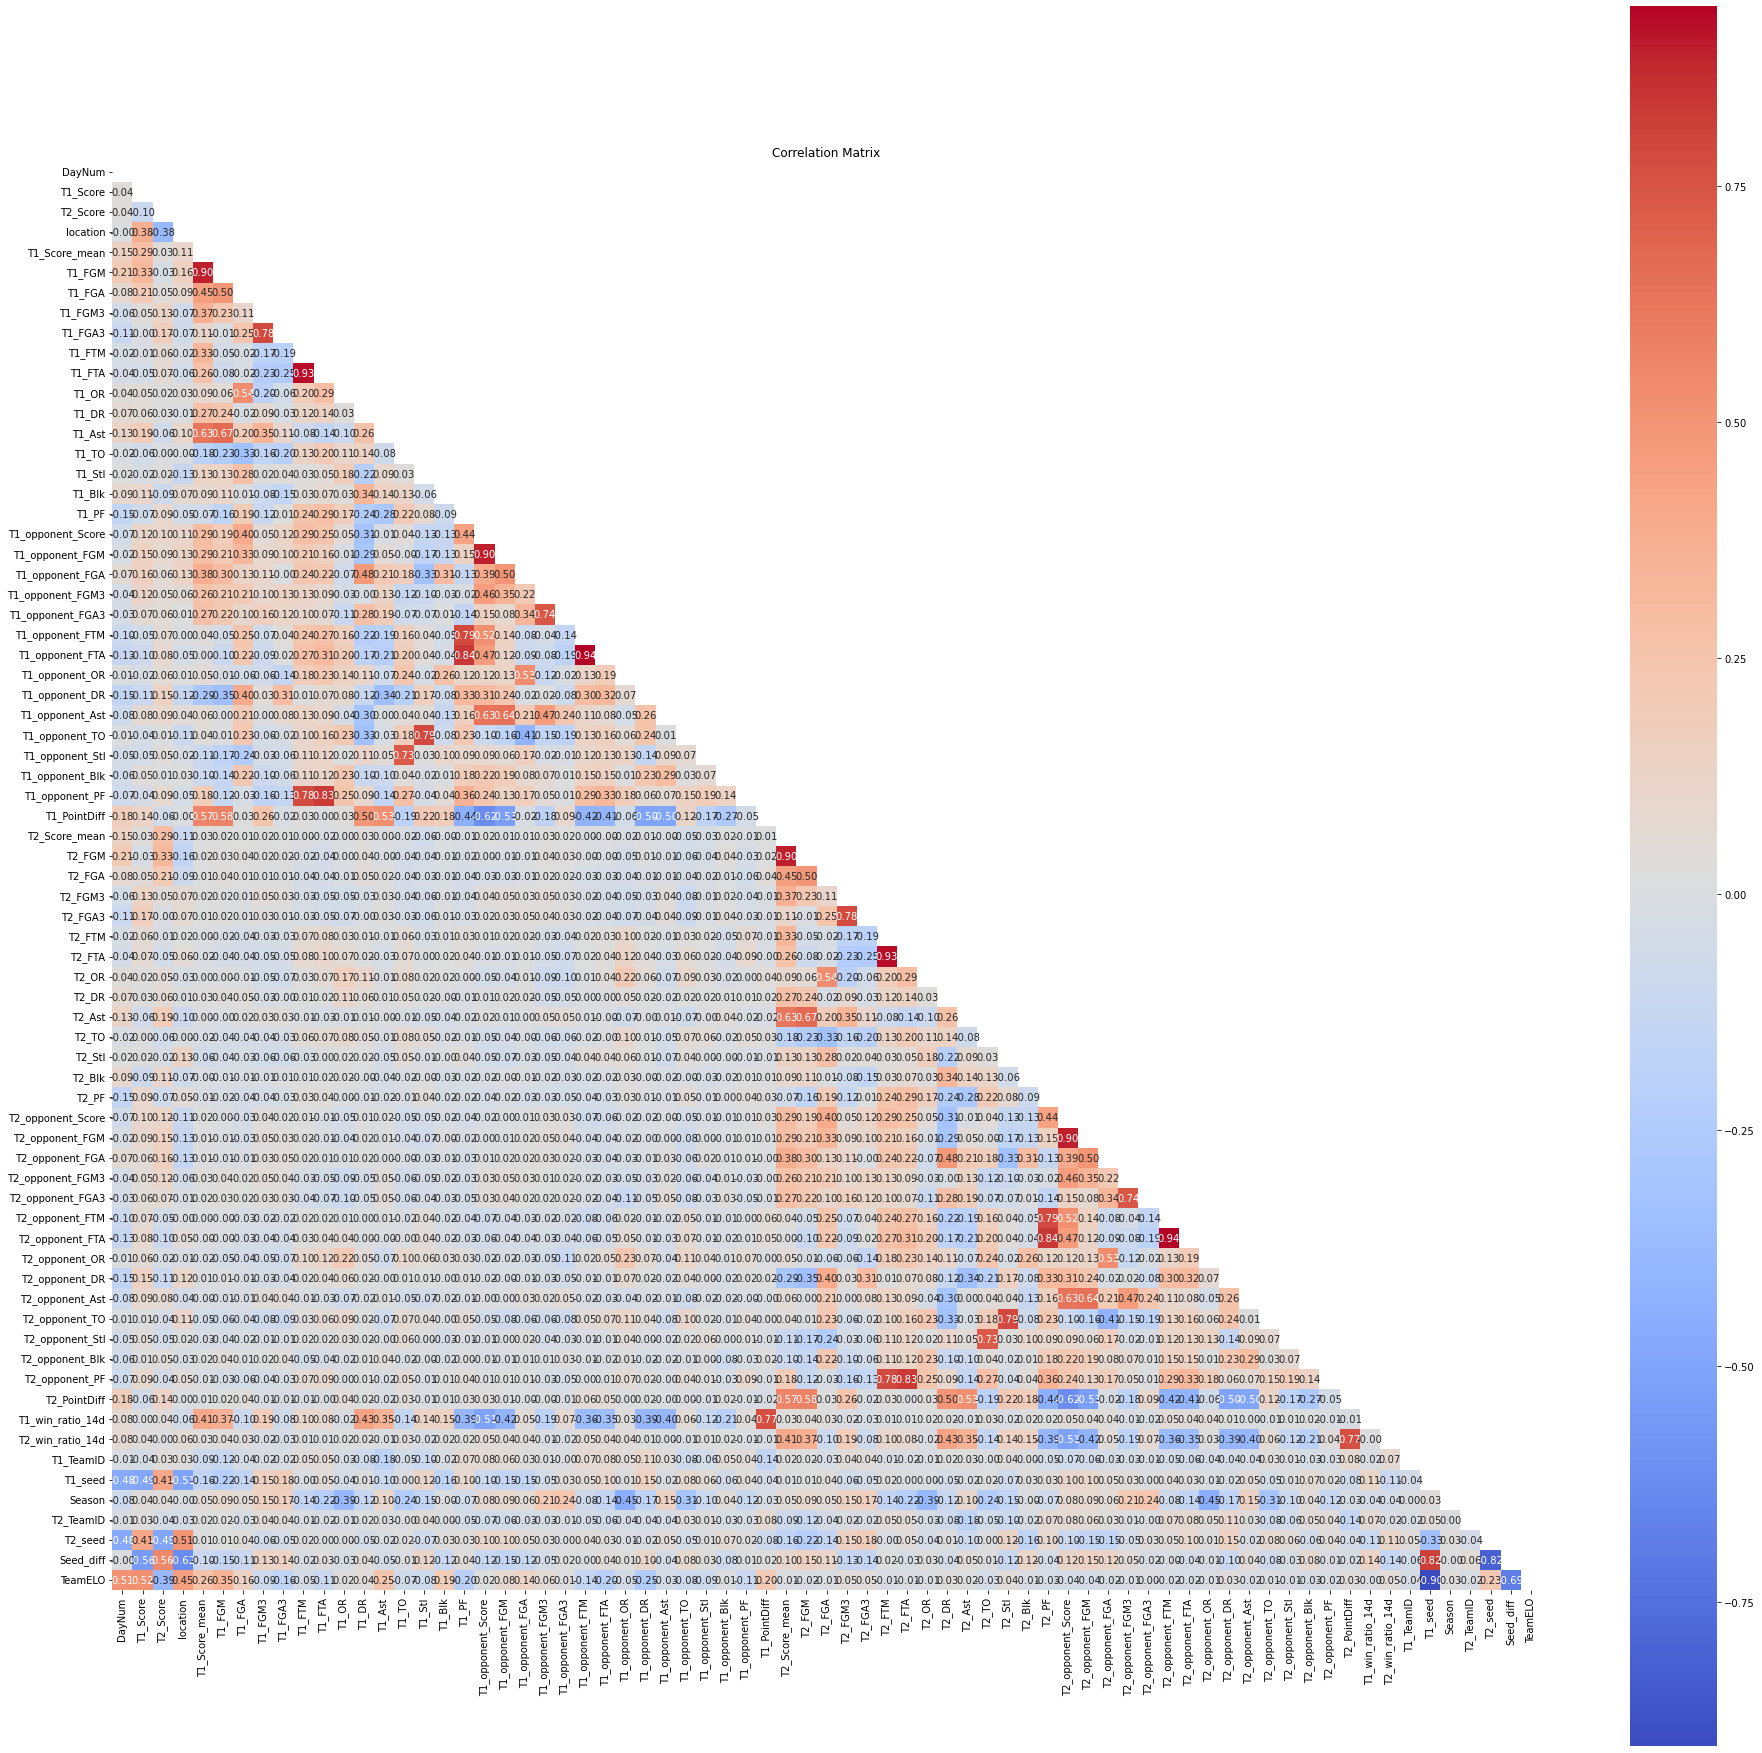

In [136]:
plot_correlation_matrix(df_train)

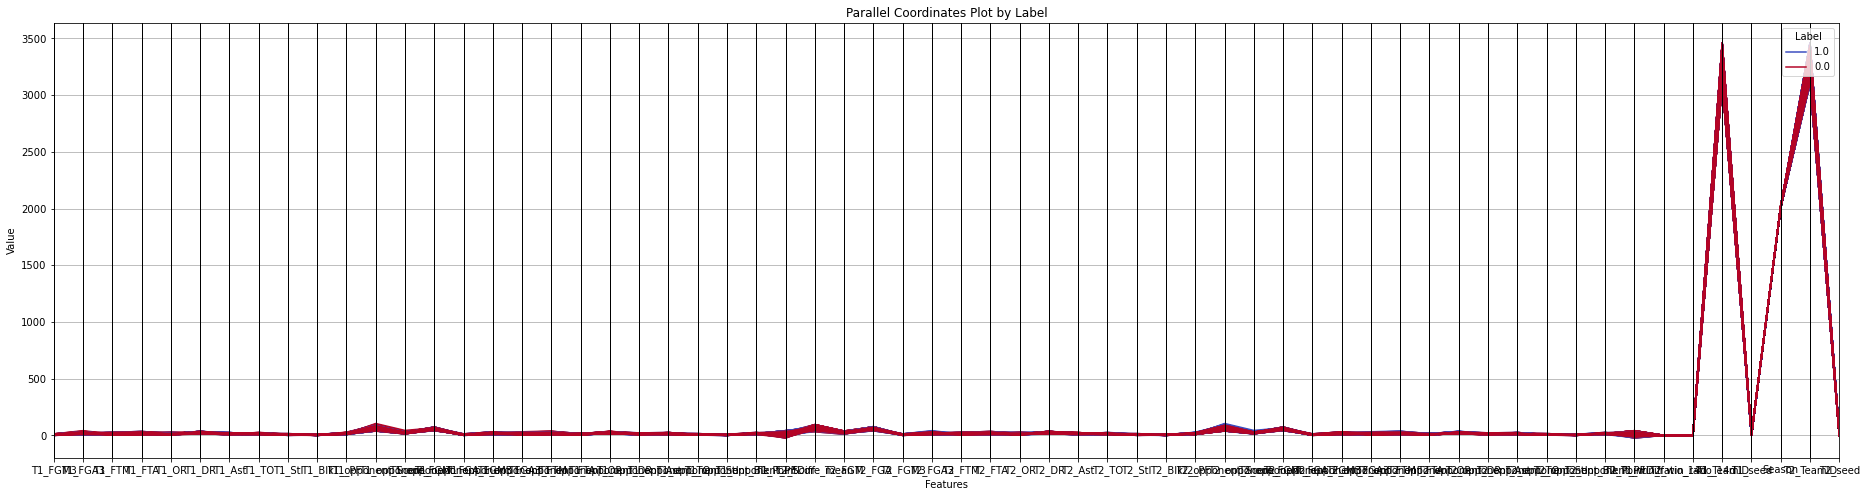

In [137]:
plot_parallel_coordinates_by_label(df_train_x.iloc[:, :-2], y_train)

In [138]:
feature_selector = widgets.SelectMultiple(
    options=list(df_train.columns),
    value=list(df_train.columns)[:5],  # default selection: first 5 features
    description='Features',
    disabled=False,
    layout=widgets.Layout(width='500px', height='300px')
)


def update_plot(selected_features):
    if selected_features:
        interactive_parallel_coordinates(df_train, y_train, list(selected_features))
    else:
        print("Please select at least one feature.")

# Create the interactive widget.
interactive_plot = widgets.interactive(update_plot, selected_features=feature_selector)
display(interactive_plot)

interactive(children=(SelectMultiple(description='Features', index=(0, 1, 2, 3, 4), layout=Layout(height='300p…

In [139]:
df_train_x

,T1_FGM3,T1_FGA3,T1_FTM,T1_FTA,T1_OR,T1_DR,T1_Ast,T1_TO,T1_Stl,T1_Blk,T1_PF,T1_opponent_Score,T1_opponent_FGM,T1_opponent_FGA,T1_opponent_FGM3,T1_opponent_FGA3,T1_opponent_FTM,T1_opponent_FTA,T1_opponent_OR,T1_opponent_DR,T1_opponent_Ast,T1_opponent_TO,T1_opponent_Stl,T1_opponent_Blk,T1_opponent_PF,T1_PointDiff,T2_Score_mean,T2_FGM,T2_FGA,T2_FGM3,T2_FGA3,T2_FTM,T2_FTA,T2_OR,T2_DR,T2_Ast,T2_TO,T2_Stl,T2_Blk,T2_PF,T2_opponent_Score,T2_opponent_FGM,T2_opponent_FGA,T2_opponent_FGM3,T2_opponent_FGA3,T2_opponent_FTM,T2_opponent_FTA,T2_opponent_OR,T2_opponent_DR,T2_opponent_Ast,T2_opponent_TO,T2_opponent_Stl,T2_opponent_Blk,T2_opponent_PF,T2_PointDiff,T1_win_ratio_14d,T2_win_ratio_14d,T1_TeamID,T1_seed,Season,T2_TeamID,T2_seed,Seed_diff,TeamELO
0,2.750000,10.750000,17.000000,23.750000,9.750000,28.750000,11.750000,15.000000,6.000000,5.000000,15.250000,63.500000,23.000000,57.750000,5.250000,16.500000,12.250000,16.750000,9.500000,26.500000,10.750000,14.750000,7.250000,3.500000,18.500000,-1.250000,78.000000,27.500000,69.500000,10.750000,27.750000,12.250000,16.750000,16.000000,27.250000,15.500000,13.250000,10.750000,3.250000,18.000000,59.000000,24.000000,57.500000,4.250000,13.750000,6.750000,16.000000,12.000000,28.500000,14.000000,20.750000,6.250000,1.750000,13.750000,19.000000,0.500000,0.75,3124,4,2010,3201,13,-9,2047.364734
1,7.000000,19.500000,13.500000,17.500000,11.500000,29.500000,14.500000,15.500000,3.000000,3.500000,21.000000,66.500000,21.500000,62.500000,4.000000,12.500000,19.500000,27.000000,16.000000,20.500000,9.500000,11.500000,7.000000,4.500000,18.500000,7.000000,61.000000,18.000000,55.000000,6.000000,20.500000,19.000000,23.500000,8.000000,21.500000,11.500000,13.000000,6.500000,0.500000,18.000000,69.500000,24.500000,50.500000,6.000000,15.500000,14.500000,19.500000,8.000000,32.000000,20.000000,18.000000,7.000000,2.500000,19.500000,-8.500000,0.500000,0.00,3173,8,2010,3395,9,-1,1803.100984
2,6.000000,12.666667,13.000000,21.666667,13.666667,20.333333,12.000000,17.000000,13.000000,5.333333,17.666667,59.666667,19.666667,51.666667,5.666667,14.666667,14.666667,18.000000,12.333333,20.666667,9.666667,22.666667,6.333333,1.666667,19.333333,8.000000,58.750000,22.000000,54.250000,3.500000,15.000000,11.250000,15.500000,11.000000,23.750000,11.250000,12.000000,7.500000,3.750000,14.750000,42.000000,15.750000,46.500000,1.250000,7.750000,9.250000,17.500000,11.000000,23.250000,4.750000,19.250000,3.750000,1.750000,15.000000,16.750000,1.000000,1.00,3181,2,2010,3214,15,-13,2222.732883
3,4.000000,28.000000,14.000000,18.000000,28.000000,16.000000,7.000000,9.000000,10.000000,1.000000,22.000000,67.000000,21.000000,43.000000,8.000000,20.000000,17.000000,20.000000,5.000000,29.000000,14.000000,18.000000,6.000000,7.000000,19.000000,-7.000000,71.600000,27.800000,62.800000,4.000000,12.200000,12.000000,19.000000,14.000000,28.000000,14.400000,14.400000,8.000000,3.000000,13.400000,67.600000,25.800000,67.200000,5.600000,20.600000,10.400000,13.600000,14.800000,24.600000,14.200000,13.600000,7.000000,3.800000,16.600000,4.000000,0.000000,0.80,3199,3,2010,3256,14,-11,2065.191353
4,4.000000,23.000000,16.000000,22.000000,18.000000,26.000000,11.000000,16.000000,11.000000,2.000000,24.000000,63.000000,16.000000,55.000000,3.000000,21.000000,28.000000,36.000000,16.000000,34.000000,9.000000,22.000000,5.000000,5.000000,21.000000,-7.000000,64.000000,22.333333,54.000000,4.666667,15.666667,14.666667,20.333333,8.333333,27.000000,11.333333,8.666667,9.000000,5.000000,9.333333,44.666667,18.000000,59.333333,4.000000,21.666667,4.666667,6.333333,15.000000,25.000000,8.000000,15.000000,6.333333,3.000000,18.666667,19.333333,0.000000,1.00,3207,5,2010,3265,12,-7,1901.415647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1649,6.000000,19.500000,14.500000,16.500000,8.500000,21.000000,2

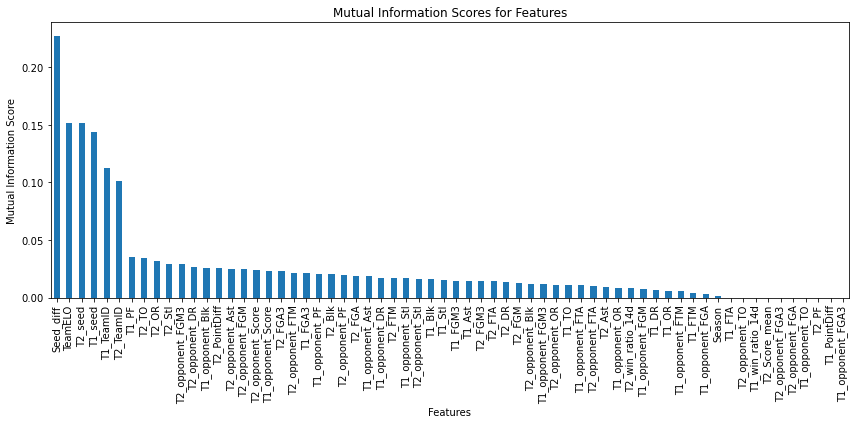

Top features by mutual information: ['T2_opponent_FTM', 'T2_FGA3', 'T1_opponent_Score', 'T2_opponent_Score', 'T2_opponent_FGM', 'T2_opponent_Ast', 'T2_PointDiff', 'T1_opponent_Blk', 'T2_opponent_DR', 'T2_opponent_FGM3', 'T2_Stl', 'T2_OR', 'T2_TO', 'T1_PF', 'T2_TeamID', 'T1_TeamID', 'T1_seed', 'T2_seed', 'TeamELO', 'Seed_diff']


In [140]:
# Example usage:
# Assuming df is your DataFrame with numeric features and y is your label array.
plot_mutual_info(df_train_x, y_train)

# Example usage:
selected_features = select_top_features_by_mutual_info(df_train_x, y_train, top_k=20)
print("Top features by mutual information:", selected_features)

In [141]:
columns_to_include = df_train.columns[:6].tolist() + ['T1_seed', 'T2_seed', 'Seed_diff', 'TeamELO']
x_train, y_train = x_y_from_data_frame(df_train[columns_to_include])
x_test, y_test = x_y_from_data_frame(df_test[columns_to_include])

df_train_x = df_train[columns_to_include].iloc[:, 6:]
df_test_x = df_test[columns_to_include].iloc[:, 6:]

x_train, y_train = clear_na_from_x_y(x_train.copy(), y_train.copy())
x_test, y_test = clear_na_from_x_y(x_test.copy(), y_test.copy())

In [155]:
print('LogisticRegressionCV')

# Create a pipeline with StandardScaler and LogisticRegressionCV
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegressionCV(
        cv=5,                # 5-fold cross-validation
        solver='lbfgs',
        max_iter=2000,       # Increase max_iter if needed
        scoring='neg_log_loss',  # Optimize log-loss for probability calibration
        refit=True
    ))
])

# Train the model using the pipeline
pipeline.fit(x_train, y_train)

y_prob = pipeline.predict_proba(x_test)[:, 1]
score = brier_score_loss(y_test, y_prob)
print("Brier score:", score)

# -----------------------------------------------------------

print('XGBClassifier')

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

# Train the model using the pipeline
pipeline.fit(x_train, y_train)

# Predict probabilities for the positive class
y_prob = pipeline.predict_proba(x_test)[:, 1]

# Calculate the Brier score
score = brier_score_loss(y_test, y_prob)
print("Brier score:", score)

LogisticRegressionCV
Brier score: 0.1297173523421587
XGBClassifier
Brier score: 0.1448934246139073


## Finding optimal featue set

In [141]:
def brier_for_all_years(year_range, season_years_list):
    
    df_train_women_list = []
    df_test_women_list = []
    df_train_men_list = []
    df_test_men_list = []
    
    for year, season_years in zip(year_range, season_years_list):
    
        final_season = year
#         season_years_list = [[i] for i in range(start_season, final_season+1)]

        for sex in ['woman', 'man']:
            
            if sex == 'woman':
                include_men = False
                include_women = True
            elif sex == 'man':
                include_men = True
                include_women = False

            # ----------------------------------------------------------
            # READ DATA
            regular_results = pd.concat([
                MRegularSeasonDetailedResults.copy() if include_men else None,
                WRegularSeasonDetailedResults.copy() if include_women else None
            ], ignore_index=True)
            tourney_results = pd.concat([
                MNCAATourneyDetailedResults.copy() if include_men else None,
                WNCAATourneyDetailedResults.copy() if include_women else None
            ], ignore_index=True)
            seeds = pd.concat([
                MNCAATourneySeeds.copy() if include_men else None,
                WNCAATourneySeeds.copy() if include_women else None
            ], ignore_index=True)
            # ----------------------------------------------------------
            # GET ALL DATA NEEDED TO USE THE MODELS
            df_train, df_test = get_all_core_data(
                regular_results, tourney_results, seeds, SampleSubmissionStage1, final_season = final_season,
                start_season = start_season, season_years_list  = season_years, days_back = days_back,
                maximum_favoured_seed = maximum_favoured_seed, location_multiplier=location_multiplier,
                include_men = include_men, include_women = include_women, win_ratio_days_back = win_ratio_days_back)
            # ----------------------------------------------------------
            # ADD TEAM AND COACH ELO AND REPLACE NAN WITH MEAN
            elo = pd.read_csv(join(data_path, 'elo.csv'))
            elo['CoachELO'] = elo['CoachELO'].fillna(elo['CoachELO'].mean())
            elo = elo.drop(['CoachName'], axis=1)
            def add_elo_column(df):
                df = df.copy()
                df = pd.merge(
                        df,
                        elo[['Season', 'DayNum', 'TeamID', 'TeamELO', 'CoachELO']],
                        left_on=['Season', 'DayNum', 'T1_TeamID'],
                        right_on=['Season', 'DayNum', 'TeamID'],
                        how='left'
                    )
                df = df.drop(['TeamID'], axis=1)
                return df
            df_train = add_elo_column(df_train)
            df_test = add_elo_column(df_test)
            # ----------------------------------------------------------
            if sex == 'woman':
                df_train_women_list.append(df_train.copy())
                df_test_women_list.append(df_test.copy())
            elif sex == 'man':
                df_train_men_list.append(df_train.copy())
                df_test_men_list.append(df_test.copy())
                
        for i in range(len(df_train_men_list)):
            df_train_women_list[i] = df_train_women_list[i][list(df_train_men_list[0])]
            df_test_women_list[i] = df_test_women_list[i][list(df_train_men_list[0])]
            
    return df_train_women_list, df_test_women_list, df_train_men_list, df_test_men_list

In [142]:
year_range = [2021, 2022, 2023, 2024]
# ----------------------------------------------------------
# PARAMETERS TO CHANGE
# final_season = 2024 # the season we want to predict, so for out submission it will be 2025
start_season = 2003 # from which ponit should we begin creating data
season_years_list  = [[[i] for i in range(start_season, year+1)] for year in year_range] # at which seasons to look at when calculating team's stats
days_back = 14 # how many days back from the start of tourney to calculate team's stats per season
maximum_favoured_seed = 1 # Set the predicted probability of winning to 1 for seeds <= maximum_favoured_seed and to 0 for >= 16-maximum_favoured_seed
location_multiplier = [0.95, 1.05] # home penalty, away bonus ex.
win_ratio_days_back = 14 # how many days back from the tourney do we calculate win ratio
df_train_women_list, df_test_women_list, df_train_men_list, df_test_men_list = brier_for_all_years(year_range, season_years_list)
# ----------------------------------------------------------
x_train_women_list = []
x_test_women_list = []
x_train_men_list = []
x_test_men_list = []
y_train_women_list = []
y_test_women_list = []
y_train_men_list = []
y_test_men_list = []
for i in range(len(year_range)):
    x_train_women, y_train_women = x_y_from_data_frame(df_train_women_list[i])
    x_test_women, y_test_women = x_y_from_data_frame(df_test_women_list[i])
    x_train_men, y_train_men = x_y_from_data_frame(df_train_men_list[i])
    x_test_men, y_test_men = x_y_from_data_frame(df_test_men_list[i])

    x_train_women, y_train_women = clear_na_from_x_y(x_train_women.copy(), y_train_women.copy())
    x_test_women, y_test_women = clear_na_from_x_y(x_test_women.copy(), y_test_women.copy())
    x_train_men, y_train_men = clear_na_from_x_y(x_train_men.copy(), y_train_men.copy())
    x_test_men, y_test_men = clear_na_from_x_y(x_test_men.copy(), y_test_men.copy())
    
    x_train_women_list.append(x_train_women)
    x_test_women_list.append(x_test_women)
    x_train_men_list.append(x_train_men)
    x_test_men_list.append(x_test_men)
    
    y_train_women_list.append(y_train_women)
    y_test_women_list.append(y_test_women)
    y_train_men_list.append(y_train_men)
    y_test_men_list.append(y_test_men)

for i in range(len(year_range)):
    print("Predictions for season ", year_range[i])
    x_train_women = x_train_women_list[i]
    y_train_women = y_train_women_list[i]
    x_test_women = x_test_women_list[i]
    y_test_women = y_test_women_list[i]
    print('LogisticRegressionCV for women trained on women')
    pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegressionCV(
                cv=5,
                solver='lbfgs',
                max_iter=2000,
                scoring='neg_log_loss',
                refit=True
            ))
    ])
    pipeline.fit(x_train_women, y_train_women)
    y_prob_women = pipeline.predict_proba(x_test_women)[:, 1]
    score = brier_score_loss(y_test_women, y_prob_women)
    print("Brier score:", score)
    # ----------------------------------------------
    x_train_men = x_train_men_list[i]
    y_train_men = y_train_men_list[i]
    x_test_men = x_test_men_list[i]
    y_test_men = y_test_men_list[i]
    print('LogisticRegressionCV for men trained on men')
    pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegressionCV(
                cv=5,
                solver='lbfgs',
                max_iter=2000,
                scoring='neg_log_loss',
                refit=True
            ))
    ])
    pipeline.fit(x_train_men, y_train_men)
    y_prob_men = pipeline.predict_proba(x_test_men)[:, 1]
    score = brier_score_loss(y_test_men, y_prob_men)
    print("Brier score:", score)
    # ----------------------------------------------
    print('LogisticRegressionCV for all trained on women and men separately')
    y_prob = np.concatenate((y_prob_women, y_prob_men))
    y_test = np.concatenate((y_test_women, y_test_men))
    score = brier_score_loss(y_test, y_prob)
    print("Brier score:", score)
    # ----------------------------------------------
    print('LogisticRegressionCV for all trained on both men and women')
    pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegressionCV(
                cv=5,
                solver='lbfgs',
                max_iter=2000,
                scoring='neg_log_loss',
                refit=True
            ))
    ])
    x_train = np.concatenate((x_train_women, x_train_men))
    y_train = np.concatenate((y_train_women, y_train_men))
    x_test = np.concatenate((x_test_women, x_test_men))
    pipeline.fit(x_train, y_train)
    y_prob = pipeline.predict_proba(x_test)[:, 1]
    score = brier_score_loss(y_test, y_prob)
    print("Brier score:", score)
    print()

Predictions for season  2021
LogisticRegressionCV for women trained on women
Brier score: 0.14498760577901523
LogisticRegressionCV for men trained on men
Brier score: 0.22314945045325432
LogisticRegressionCV for all trained on women and men separately
Brier score: 0.18497738677513756
LogisticRegressionCV for all trained on both men and women
Brier score: 0.1886213840360878

Predictions for season  2022
LogisticRegressionCV for women trained on women
Brier score: 0.17022893322976282
LogisticRegressionCV for men trained on men
Brier score: 0.20529662769150692
LogisticRegressionCV for all trained on women and men separately
Brier score: 0.1878926608104932
LogisticRegressionCV for all trained on both men and women
Brier score: 0.18727534753008093

Predictions for season  2023
LogisticRegressionCV for women trained on women
Brier score: 0.17436088549295045
LogisticRegressionCV for men trained on men
Brier score: 0.20435789460876785
LogisticRegressionCV for all trained on women and men separ

In [143]:
year_range = [2021, 2022, 2023, 2024]
# ----------------------------------------------------------
# PARAMETERS TO CHANGE
# final_season = 2024 # the season we want to predict, so for out submission it will be 2025
start_season = 2003 # from which ponit should we begin creating data
season_years_list  = [[[i-1, i] for i in range(start_season, year+1)] for year in year_range] # at which seasons to look at when calculating team's stats
days_back = 14 # how many days back from the start of tourney to calculate team's stats per season
maximum_favoured_seed = 1 # Set the predicted probability of winning to 1 for seeds <= maximum_favoured_seed and to 0 for >= 16-maximum_favoured_seed
location_multiplier = [0.95, 1.05] # home penalty, away bonus ex.
win_ratio_days_back = 14 # how many days back from the tourney do we calculate win ratio
df_train_women_list, df_test_women_list, df_train_men_list, df_test_men_list = brier_for_all_years(year_range, season_years_list)
# ----------------------------------------------------------
x_train_women_list = []
x_test_women_list = []
x_train_men_list = []
x_test_men_list = []
y_train_women_list = []
y_test_women_list = []
y_train_men_list = []
y_test_men_list = []
for i in range(len(year_range)):
    x_train_women, y_train_women = x_y_from_data_frame(df_train_women_list[i])
    x_test_women, y_test_women = x_y_from_data_frame(df_test_women_list[i])
    x_train_men, y_train_men = x_y_from_data_frame(df_train_men_list[i])
    x_test_men, y_test_men = x_y_from_data_frame(df_test_men_list[i])

    x_train_women, y_train_women = clear_na_from_x_y(x_train_women.copy(), y_train_women.copy())
    x_test_women, y_test_women = clear_na_from_x_y(x_test_women.copy(), y_test_women.copy())
    x_train_men, y_train_men = clear_na_from_x_y(x_train_men.copy(), y_train_men.copy())
    x_test_men, y_test_men = clear_na_from_x_y(x_test_men.copy(), y_test_men.copy())
    
    x_train_women_list.append(x_train_women)
    x_test_women_list.append(x_test_women)
    x_train_men_list.append(x_train_men)
    x_test_men_list.append(x_test_men)
    
    y_train_women_list.append(y_train_women)
    y_test_women_list.append(y_test_women)
    y_train_men_list.append(y_train_men)
    y_test_men_list.append(y_test_men)

for i in range(len(year_range)):
    print("Predictions for season ", year_range[i])
    x_train_women = x_train_women_list[i]
    y_train_women = y_train_women_list[i]
    x_test_women = x_test_women_list[i]
    y_test_women = y_test_women_list[i]
    print('LogisticRegressionCV for women trained on women')
    pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegressionCV(
                cv=5,
                solver='lbfgs',
                max_iter=2000,
                scoring='neg_log_loss',
                refit=True
            ))
    ])
    pipeline.fit(x_train_women, y_train_women)
    y_prob_women = pipeline.predict_proba(x_test_women)[:, 1]
    score = brier_score_loss(y_test_women, y_prob_women)
    print("Brier score:", score)
    # ----------------------------------------------
    x_train_men = x_train_men_list[i]
    y_train_men = y_train_men_list[i]
    x_test_men = x_test_men_list[i]
    y_test_men = y_test_men_list[i]
    print('LogisticRegressionCV for men trained on men')
    pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegressionCV(
                cv=5,
                solver='lbfgs',
                max_iter=2000,
                scoring='neg_log_loss',
                refit=True
            ))
    ])
    pipeline.fit(x_train_men, y_train_men)
    y_prob_men = pipeline.predict_proba(x_test_men)[:, 1]
    score = brier_score_loss(y_test_men, y_prob_men)
    print("Brier score:", score)
    # ----------------------------------------------
    print('LogisticRegressionCV for all trained on women and men separately')
    y_prob = np.concatenate((y_prob_women, y_prob_men))
    y_test = np.concatenate((y_test_women, y_test_men))
    score = brier_score_loss(y_test, y_prob)
    print("Brier score:", score)
    # ----------------------------------------------
    print('LogisticRegressionCV for all trained on both men and women')
    pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegressionCV(
                cv=5,
                solver='lbfgs',
                max_iter=2000,
                scoring='neg_log_loss',
                refit=True
            ))
    ])
    x_train = np.concatenate((x_train_women, x_train_men))
    y_train = np.concatenate((y_train_women, y_train_men))
    x_test = np.concatenate((x_test_women, x_test_men))
    pipeline.fit(x_train, y_train)
    y_prob = pipeline.predict_proba(x_test)[:, 1]
    score = brier_score_loss(y_test, y_prob)
    print("Brier score:", score)
    print()

Predictions for season  2021
LogisticRegressionCV for women trained on women
Brier score: 0.14498760577901523
LogisticRegressionCV for men trained on men
Brier score: 0.22314945045325432
LogisticRegressionCV for all trained on women and men separately
Brier score: 0.18497738677513756
LogisticRegressionCV for all trained on both men and women
Brier score: 0.1886213840360878

Predictions for season  2022
LogisticRegressionCV for women trained on women
Brier score: 0.17022893322976282
LogisticRegressionCV for men trained on men
Brier score: 0.20529662769150692
LogisticRegressionCV for all trained on women and men separately
Brier score: 0.1878926608104932
LogisticRegressionCV for all trained on both men and women
Brier score: 0.18727534753008093

Predictions for season  2023
LogisticRegressionCV for women trained on women
Brier score: 0.17436088549295045
LogisticRegressionCV for men trained on men
Brier score: 0.20435789460876785
LogisticRegressionCV for all trained on women and men separ

In [146]:
year_range = [2021, 2022, 2023, 2024]
# ----------------------------------------------------------
# PARAMETERS TO CHANGE
# final_season = 2024 # the season we want to predict, so for out submission it will be 2025
start_season = 2005 # from which ponit should we begin creating data
season_years_list  = [[[i-2, i-1, i] for i in range(start_season, year+1)] for year in year_range] # at which seasons to look at when calculating team's stats
days_back = 25 # how many days back from the start of tourney to calculate team's stats per season
maximum_favoured_seed = 1 # Set the predicted probability of winning to 1 for seeds <= maximum_favoured_seed and to 0 for >= 16-maximum_favoured_seed
location_multiplier = [0.95, 1.05] # home penalty, away bonus ex.
win_ratio_days_back = 14 # how many days back from the tourney do we calculate win ratio
df_train_women_list, df_test_women_list, df_train_men_list, df_test_men_list = brier_for_all_years(year_range, season_years_list)
# ----------------------------------------------------------
x_train_women_list = []
x_test_women_list = []
x_train_men_list = []
x_test_men_list = []
y_train_women_list = []
y_test_women_list = []
y_train_men_list = []
y_test_men_list = []
for i in range(len(year_range)):
    x_train_women, y_train_women = x_y_from_data_frame(df_train_women_list[i])
    x_test_women, y_test_women = x_y_from_data_frame(df_test_women_list[i])
    x_train_men, y_train_men = x_y_from_data_frame(df_train_men_list[i])
    x_test_men, y_test_men = x_y_from_data_frame(df_test_men_list[i])

    x_train_women, y_train_women = clear_na_from_x_y(x_train_women.copy(), y_train_women.copy())
    x_test_women, y_test_women = clear_na_from_x_y(x_test_women.copy(), y_test_women.copy())
    x_train_men, y_train_men = clear_na_from_x_y(x_train_men.copy(), y_train_men.copy())
    x_test_men, y_test_men = clear_na_from_x_y(x_test_men.copy(), y_test_men.copy())
    
    x_train_women_list.append(x_train_women)
    x_test_women_list.append(x_test_women)
    x_train_men_list.append(x_train_men)
    x_test_men_list.append(x_test_men)
    
    y_train_women_list.append(y_train_women)
    y_test_women_list.append(y_test_women)
    y_train_men_list.append(y_train_men)
    y_test_men_list.append(y_test_men)

for i in range(len(year_range)):
    print("Predictions for season ", year_range[i])
    x_train_women = x_train_women_list[i]
    y_train_women = y_train_women_list[i]
    x_test_women = x_test_women_list[i]
    y_test_women = y_test_women_list[i]
    print('LogisticRegressionCV for women trained on women')
    pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegressionCV(
                cv=5,
                solver='lbfgs',
                max_iter=2000,
                scoring='neg_log_loss',
                refit=True
            ))
    ])
    pipeline.fit(x_train_women, y_train_women)
    y_prob_women = pipeline.predict_proba(x_test_women)[:, 1]
    score = brier_score_loss(y_test_women, y_prob_women)
    print("Brier score:", score)
    # ----------------------------------------------
    x_train_men = x_train_men_list[i]
    y_train_men = y_train_men_list[i]
    x_test_men = x_test_men_list[i]
    y_test_men = y_test_men_list[i]
    print('LogisticRegressionCV for men trained on men')
    pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegressionCV(
                cv=5,
                solver='lbfgs',
                max_iter=2000,
                scoring='neg_log_loss',
                refit=True
            ))
    ])
    pipeline.fit(x_train_men, y_train_men)
    y_prob_men = pipeline.predict_proba(x_test_men)[:, 1]
    score = brier_score_loss(y_test_men, y_prob_men)
    print("Brier score:", score)
    # ----------------------------------------------
    print('LogisticRegressionCV for all trained on women and men separately')
    y_prob = np.concatenate((y_prob_women, y_prob_men))
    y_test = np.concatenate((y_test_women, y_test_men))
    score = brier_score_loss(y_test, y_prob)
    print("Brier score:", score)
    # ----------------------------------------------
    print('LogisticRegressionCV for all trained on both men and women')
    pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegressionCV(
                cv=5,
                solver='lbfgs',
                max_iter=2000,
                scoring='neg_log_loss',
                refit=True
            ))
    ])
    x_train = np.concatenate((x_train_women, x_train_men))
    y_train = np.concatenate((y_train_women, y_train_men))
    x_test = np.concatenate((x_test_women, x_test_men))
    pipeline.fit(x_train, y_train)
    y_prob = pipeline.predict_proba(x_test)[:, 1]
    score = brier_score_loss(y_test, y_prob)
    print("Brier score:", score)
    print()

Predictions for season  2021
LogisticRegressionCV for women trained on women
Brier score: 0.15486429471467572
LogisticRegressionCV for men trained on men
Brier score: 0.21773192269461852
LogisticRegressionCV for all trained on women and men separately
Brier score: 0.18702912763464646
LogisticRegressionCV for all trained on both men and women
Brier score: 0.18849535441843376

Predictions for season  2022
LogisticRegressionCV for women trained on women
Brier score: 0.1722081203721447
LogisticRegressionCV for men trained on men
Brier score: 0.2071572232609805
LogisticRegressionCV for all trained on women and men separately
Brier score: 0.18981211293837305
LogisticRegressionCV for all trained on both men and women
Brier score: 0.18495866318210383

Predictions for season  2023
LogisticRegressionCV for women trained on women
Brier score: 0.17538449942618298
LogisticRegressionCV for men trained on men
Brier score: 0.1982478163692683
LogisticRegressionCV for all trained on women and men separa